In [50]:
import sys
sys.path.append("../..")

from transportnet import net
from transportnet import line
from transportnet import vehicle
from transportnet import passenger
from stochastic import stochastic

# from genetics import ga

import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as ss

## Define the public transport network

In [ ]:
n = net.Net()

# define the network configuration
n.load_from_file('zg_net.txt')

# define a set of public transport lines
zg_lines =  [   
    line.Line(n, [1, 2, 3, 4, 5, 6, 7, 8, 9, 181, 10, 11, 12, 13, 14, 15, 16, 17,
        16, 15, 14, 13, 12, 11, 10, 181, 9, 8, 7, 6, 5, 4, 3, 2, 1], [1, 17]),
    line.Line(n, [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 10, 29, 30, 31, 32, 33, 34,
        33, 32, 31, 30, 29, 10, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18], [18, 34]),
    line.Line(n, [60, 58, 37, 38, 39, 40, 41, 8, 9, 181, 10, 29, 30, 57, 56, 55, 54, 53, 52, 51, 50,
        51, 52, 53, 54, 55, 56, 57, 30, 29, 10, 181, 9, 8, 41, 40, 39, 38, 37, 58, 59, 60], [60, 50]),
    line.Line(n, [60, 58, 37, 38, 39, 40, 41, 8, 9, 181, 10, 11, 66, 67, 68, 69, 70, 71, 72,
        71, 70, 69, 68, 67, 66, 11, 10, 181, 9, 8, 41, 40, 39, 38, 37, 58, 59, 60], [60, 72]),
    line.Line(n, [50, 51, 52, 53, 75, 74, 73, 42, 41, 8, 9, 181, 10, 11, 66, 67, 68, 69, 70, 71, 72,
        71, 70, 69, 68, 67, 66, 11, 10, 181, 9, 8, 41, 42, 73, 74, 75, 53, 52, 51, 50], [50, 72]),
    line.Line(n, [1, 2, 3, 37, 38, 39, 40, 41, 8, 9, 181, 10, 11, 12, 13, 14, 15, 16, 17,
        16, 15, 14, 13, 12, 11, 10, 181, 9, 8, 41, 40, 39, 38, 37, 3, 2, 1], [1, 50])
]

# add vehicles # lines: 0, 1, 5, 8, 19, 80
for ln in zg_lines:
    ln.add_vehicles([vehicle.Vehicle(45) for _ in range(2)])
n.lines.extend(zg_lines)
    
# define demand intensity
# set random intervals of passengers' arrivals
s_mean_interval = stochastic.Stochastic(law=0, location=1, scale=4)
for nd in n.nodes:
    nd.s_interval = stochastic.Stochastic(law=2, scale=s_mean_interval.get_value())

## Read ODM

In [26]:
odm = {}
f = open('trips_from_visum.csv', 'r')
lines = f.readlines()
for line in lines[1:]:
    data = line.strip().split(sep=';')
    orgn, dest = int(data[0]), int(data[1])
    if orgn == dest: continue
    if orgn not in odm.keys():
        odm[orgn] = {}
    odm[orgn][dest] = float(data[3])
f.close()
# odm

## Demand generating method

In [43]:
def gen_demand(n: net.Net, odm: dict, duration: float = 60):
    n.demand = []
    for orgn in odm.keys():
        source = n.get_node(orgn)
        if source is None: continue
        for dest in odm[orgn].keys():
            target = n.get_node(dest)
            if target is None: continue
            if odm[orgn][dest] <= 0: continue
            destination_nodes = n.define_destinations(source, target)
            # show connections with transfers
            # if len(destination_nodes) > 1:
            #     print([source.code] + [nd.code for nd in destination_nodes])
            s_interval = stochastic.Stochastic(law=2, scale=60./odm[orgn][dest])
            time = round(s_interval.get_value(), 1)
            while time <= duration:
                new_passenger = passenger.Passenger(net=n)
                new_passenger.m_appearance = time
                new_passenger.origin_node = source
                new_passenger.destination_nodes = destination_nodes
                new_passenger.reset() # set initial values of boarding and disembarkation times
                source.pass_out.append(new_passenger)
                n.demand.append(new_passenger)
                time += round(s_interval.get_value(), 1)

# by default - random intervals, random destinations
n.gen_demand(60)
print(len(n.demand))
# considering the provided ODM
gen_demand(n, odm, 60)
print(len(n.demand))

1452
2166


## Simulate net

In [58]:
sim_time = 1.0 * 60
n.duration = sim_time
model_runs = 5

def fitness_function(shifts, runs=model_runs):
    res = []
    for _ in range(runs):
        n.reset()
        for idx in range(len(n.lines)):
            n.lines[idx].schedule_shift = shifts[idx]
        # n.gen_demand(duration=n.duration) # old approach
        gen_demand(n, odm, sim_time) # new approach
        x = n.simulate(sim_time)
        res.append(x)
        
        # show detailed results
        # service_started = [p for p in n.demand if p.service_started]
        # service_finished = [p for p in n.demand if p.service_finished]
        # wt_started = sum([p.wait_time for p in service_started])
        # wt_finished = sum([p.wait_time for p in service_finished])
        # print("all passengers", x, len(n.demand))
        # print("service started", wt_started / len(service_started), len(service_started))
        # print("service finished", wt_finished / len(service_finished), len(service_finished))
        # print()
    
    return np.array(res)

mean_ff = lambda xs: fitness_function(xs).mean()

mean_ff([8, 1, 15, 5, 0, 2]), mean_ff([0, 0, 0, 0, 0, 0])

(np.float64(25.66262733057328), np.float64(25.81755047573474))

In [55]:
def plot_hist(sample):
    xs = np.linspace(min(sample), max(sample), 100)
    params = ss.norm.fit(sample)
    print(params)
    bins = 1 + int(np.log2(len(sample)))
    plt.figure(dpi=150)
    plt.hist(sample, bins=bins, density=True,
             label='empirical distribution')
    plt.plot(xs, ss.norm.pdf(xs, *params), linestyle='--', color='darkgreen',
             label='normal distribution')
    plt.axvline(sample.mean(), linestyle='--', color='darkred',
                label='mean value')
    plt.xlabel('Average waiting time [min./pass.]')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    plt.show()

(np.float64(25.781553282578507), np.float64(0.3826600239211554))


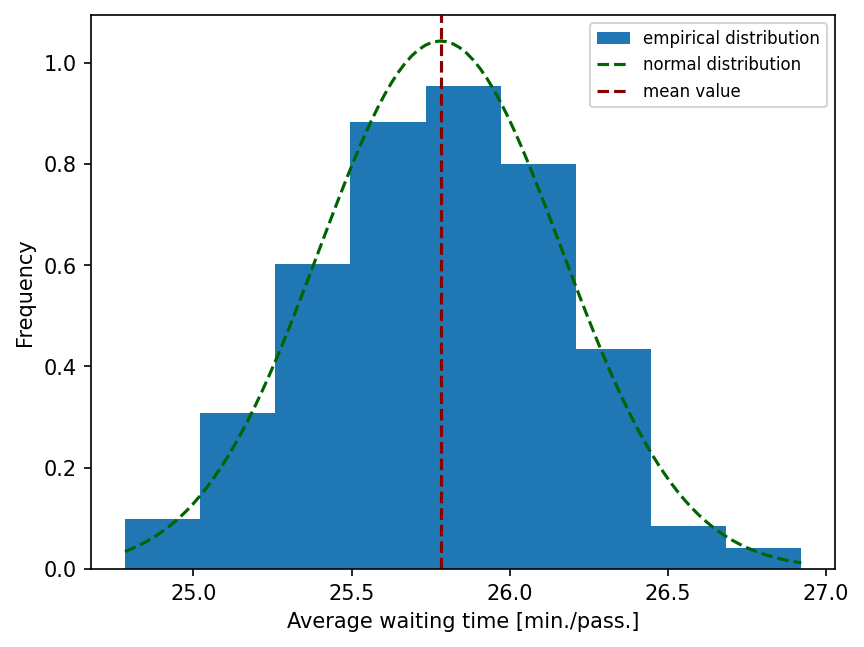

In [56]:
res = fitness_function([8, 1, 15, 5, 0, 2], runs=300)
plot_hist(res)